In [2]:
# Import Library
import yfinance as yf
import talib as ta
import urllib.parse
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
np.nan
from textblob import TextBlob
import re
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from imblearn.over_sampling import SMOTE
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [3]:
# Load News from Google
df_news_google= pd.read_csv("headlines_revised.csv")
df_news_google.head()

,keyword,headline,link,date
0,rate,Exchange Rates - Bank Negara Malaysia,https://news.google.com/rss/articles/CBMiTkFVX...,2020-12-16 16:53:28
1,rate,Personal Financing-i - myaeoncredit.com.my,https://news.google.com/rss/articles/CBMiaEFVX...,2024-03-29 15:25:24
2,rate,Traveler's Guide - Customs.gov.my,https://news.google.com/rss/articles/CBMiYEFVX...,2024-01-16 05:12:44
3,rate,ONE-X PREPAID - onexox.my,https://news.google.com/rss/articles/CBMiR0FVX...,2023-01-31 23:20:56
4,rate,Employer's Responsibilities - KWSP Malaysia - ...,https://news.google.com/rss/articles/CBMiYkFVX...,2024-01-14 08:00:00


In [4]:
# Load the CSV with multi-level headers
df_index = pd.read_csv('KLCI_Historical_Data.csv', header=[0, 1], skiprows = 1)

# Flatten multi-level headers
df_index.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_index.columns.values]

# Rename the first column to 'Date'
df_index = df_index.rename(columns={df_index.columns[0]: 'date'})

# Convert 'date' column to datetime format
df_index['date'] = pd.to_datetime(df_index['date'])

# Preview
print(df_index.head())


        date  ^KLSE_Unnamed: 1_level_1  ^KLSE_Unnamed: 2_level_1  \
0 2019-01-02               1668.109985               1694.099976   
1 2019-01-03               1675.829956               1680.780029   
2 2019-01-04               1669.780029               1676.550049   
3 2019-01-07               1679.170044               1687.130005   
4 2019-01-08               1672.760010               1686.369995   

   ^KLSE_Unnamed: 3_level_1  ^KLSE_Unnamed: 4_level_1  \
0               1666.069946               1693.510010   
1               1666.219971               1675.160034   
2               1668.150024               1672.579956   
3               1673.030029               1674.920044   
4               1670.670044               1685.719971   

   ^KLSE_Unnamed: 5_level_1  
0                  47769800  
1                  69484500  
2                  64869000  
3                 144668500  
4                 176071900  


In [5]:
# dataset shapes
df_news_google.shape, df_index.shape

((841, 4), (1470, 6))

In [6]:
# remove 'link' column
df_news = df_news_google.drop(columns=['link','keyword'])

In [7]:
# Rename columns to be consistent
df_news.rename(columns={'date': 'Date'}, inplace=True)
df_index.rename(columns={'date': 'Date'}, inplace=True) 

# Ensure both 'Date' columns are in datetime format and named the same
df_news['Date'] = pd.to_datetime(df_news['Date']).dt.date
df_index['Date'] = pd.to_datetime(df_index['Date']).dt.date


In [8]:
print(df_news.columns)
print(df_index.columns)

Index(['headline', 'Date'], dtype='object')
Index(['Date', '^KLSE_Unnamed: 1_level_1', '^KLSE_Unnamed: 2_level_1',
       '^KLSE_Unnamed: 3_level_1', '^KLSE_Unnamed: 4_level_1',
       '^KLSE_Unnamed: 5_level_1'],
      dtype='object')


In [9]:
# Rename the columns in df_index
df_index = df_index.rename(columns={
    '^KLSE_Unnamed: 1_level_1': 'Close',
    '^KLSE_Unnamed: 2_level_1': 'High',
    '^KLSE_Unnamed: 3_level_1': 'Low',
    '^KLSE_Unnamed: 4_level_1': 'Open',
    '^KLSE_Unnamed: 5_level_1': 'Volume'
})
df_index

,Date,Close,High,Low,Open,Volume
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900
...,...,...,...,...,...,...
1465,2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400
1466,2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600
1467,2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200
1468,2024-12-30,1637.680054,1638.560059,1624.920044,1626.140015,134711300


DATA CLEANING

In [10]:
# Function to check if a headline is clean (only contains standard printable characters)
def is_clean_text(text):
    return bool(re.match(r'^[A-Za-z0-9\s.,;:?!\'\"()\-&%$@]+$', text))

# Apply the filter
df_news_cleaned = df_news[df_news['headline'].apply(is_clean_text)]

# Optionally, reset index
df_news_cleaned = df_news_cleaned.reset_index(drop=True)

# Preview result
print(df_news_cleaned.head())


                                            headline        Date
0              Exchange Rates - Bank Negara Malaysia  2020-12-16
1         Personal Financing-i - myaeoncredit.com.my  2024-03-29
2                  Traveler's Guide - Customs.gov.my  2024-01-16
3                          ONE-X PREPAID - onexox.my  2023-01-31
4  Employer's Responsibilities - KWSP Malaysia - ...  2024-01-14


In [11]:
# Ensure 'Date' columns are datetime objects and have no time component
df_index['Date'] = pd.to_datetime(df_index['Date']).dt.date
df_news_cleaned['Date'] = pd.to_datetime(df_news_cleaned['Date']).dt.date

# Merge: keep all index dates, match news where available
df_combined = pd.merge(df_index, df_news_cleaned, on='Date', how='left')
df_combined


,Date,Close,High,Low,Open,Volume,headline
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,NaN
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,NaN
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,NaN
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,NaN
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,NaN
...,...,...,...,...,...,...,...
1643,2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200,"Consulate General of Malaysia, Xian - kln.gov.my"
1644,2024-12-30,1637.680054,1638.560059,1624.920044,1626.140015,134711300,Bursa Malaysia registers net outflow of RM231....
1645,2024-12-31,1642.329956,1644.540039,1632.849976,1638.430054,161319700,Detailed Disclosure of International Reserves ...
1646,2024-12-31,1642.329956,1644.540039,1632.849976,1638.430054,161319700,Monetary and Financial Developments in Novembe...


In [12]:
# Group headlines by Date (join multiple headlines into one string)
aggregated_news = df_news_cleaned.groupby('Date')['headline'].apply(' | '.join).reset_index()

# Left join to retain all dates from the index
df_combined = df_index.merge(aggregated_news, on='Date', how='left')


In [13]:
# Replace NaN with empty string if preferred
df_combined['headline'] = df_combined['headline'].fillna('')

# Export
df_combined.to_csv('klci_with_headlines.csv', index=False)
df_combined


,Date,Close,High,Low,Open,Volume,headline
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,
...,...,...,...,...,...,...,...
1465,2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400,IHH Annual Report 2023 - INSAGE (MSC) SDN BHD ...
1466,2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600,
1467,2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200,"Consulate General of Malaysia, Xian - kln.gov.my"
1468,2024-12-30,1637.680054,1638.560059,1624.920044,1626.140015,134711300,Bursa Malaysia registers net outflow of RM231....


SENTIMENT ANALYSIS USING TEXTBLOB AND VADER

In [14]:
#Sentiment Analysis using TextBlob
# get subjectivity:
def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

# get polarity:
def get_polarity(text):
    return TextBlob(text).sentiment.polarity

In [15]:
#Get Subjectivity and polarity 
df_combined['TextBlob_Polarity'] = df_combined['headline'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_combined['TextBlob_Subjectivity'] = df_combined['headline'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Preview results
print(df_combined[['headline', 'TextBlob_Polarity', 'TextBlob_Subjectivity', ]].head())

# save to CSV
df_combined.to_csv('news_sentiment_revised.csv', index=False)

  headline  TextBlob_Polarity  TextBlob_Subjectivity
0                         0.0                    0.0
1                         0.0                    0.0
2                         0.0                    0.0
3                         0.0                    0.0
4                         0.0                    0.0


In [16]:
df_text = pd.read_csv('news_sentiment_revised.csv')
df_text

,Date,Close,High,Low,Open,Volume,headline,TextBlob_Polarity,TextBlob_Subjectivity
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,NaN,0.0000,0.0000
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,NaN,0.0000,0.0000
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,NaN,0.0000,0.0000
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,NaN,0.0000,0.0000
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,NaN,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...
1465,2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400,IHH Annual Report 2023 - INSAGE (MSC) SDN BHD ...,0.0000,0.0000
1466,2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600,NaN,0.0000,0.0000
1467,2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200,"Consulate General of Malaysia, Xian - kln.gov.my",0.0500,0.5000
1468,2024-12-30,1637.680054,1638.560059,1624.920044,1626.140015,134711300,Bursa Malaysia registers net outflow of RM231....,-0.0625,0.0625


In [17]:
# Define sentiment category function
def get_sentiment(polarity):
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment category
df_text['TextBlob_Sentiment'] = df_text['TextBlob_Polarity'].apply(get_sentiment)

# Preview
print(df_text[['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'headline', 'TextBlob_Polarity', 'TextBlob_Subjectivity', 'TextBlob_Sentiment']].head())


         Date        Close         High          Low         Open     Volume  \
0  2019-01-02  1668.109985  1694.099976  1666.069946  1693.510010   47769800   
1  2019-01-03  1675.829956  1680.780029  1666.219971  1675.160034   69484500   
2  2019-01-04  1669.780029  1676.550049  1668.150024  1672.579956   64869000   
3  2019-01-07  1679.170044  1687.130005  1673.030029  1674.920044  144668500   
4  2019-01-08  1672.760010  1686.369995  1670.670044  1685.719971  176071900   

  headline  TextBlob_Polarity  TextBlob_Subjectivity TextBlob_Sentiment  
0      NaN                0.0                    0.0            Neutral  
1      NaN                0.0                    0.0            Neutral  
2      NaN                0.0                    0.0            Neutral  
3      NaN                0.0                    0.0            Neutral  
4      NaN                0.0                    0.0            Neutral  


In [18]:
# SENTIMENT ANALYSIS USING VADER
# Initialize VADER
sia = SentimentIntensityAnalyzer()

In [19]:
# Ensure all values in 'headline' column are strings and fill NaNs
df_text['headline'] = df_text['headline'].fillna("").astype(str)

# Apply sentiment scoring
df_text['VADER_Score'] = df_text['headline'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Categorize sentiment
def categorize_vader(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_text['VADER_Sentiment'] = df_text['VADER_Score'].apply(categorize_vader)

# Preview result
df_text.head()


,Date,Close,High,Low,Open,Volume,headline,TextBlob_Polarity,TextBlob_Subjectivity,TextBlob_Sentiment,VADER_Score,VADER_Sentiment
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,,0.0,0.0,Neutral,0.0,Neutral
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,,0.0,0.0,Neutral,0.0,Neutral
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,,0.0,0.0,Neutral,0.0,Neutral
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,,0.0,0.0,Neutral,0.0,Neutral
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,,0.0,0.0,Neutral,0.0,Neutral


In [20]:
df_merged= df_text[['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'headline','TextBlob_Polarity', 'TextBlob_Subjectivity','TextBlob_Sentiment', 'VADER_Score', 'VADER_Sentiment']]

# Export to CSV
df_merged.to_csv('merged_sentiments_revised.csv', index=False)
df_merged

,Date,Close,High,Low,Open,Volume,headline,TextBlob_Polarity,TextBlob_Subjectivity,TextBlob_Sentiment,VADER_Score,VADER_Sentiment
0,2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,,0.0000,0.0000,Neutral,0.0000,Neutral
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,,0.0000,0.0000,Neutral,0.0000,Neutral
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,,0.0000,0.0000,Neutral,0.0000,Neutral
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,,0.0000,0.0000,Neutral,0.0000,Neutral
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,,0.0000,0.0000,Neutral,0.0000,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...
1465,2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400,IHH Annual Report 2023 - INSAGE (MSC) SDN BHD ...,0.0000,0.0000,Neutral,0.0000,Neutral
1466,2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600,,0.0000,0.0000,Neutral,0.0000,Neutral
1467,2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200,"Consulate General of Malaysia, Xian - kln.gov.my",0.0500,0.5000,Neutral,0.0000,Neutral
1468,2024-12-30,1637.680054,1638.560059,1624.920044,1626.140015,134711300,Bursa Malaysia registers net outflow of RM231....,-0.0625,0.0625,Negative,0.0000,Neutral


DATA VISUALIZATION

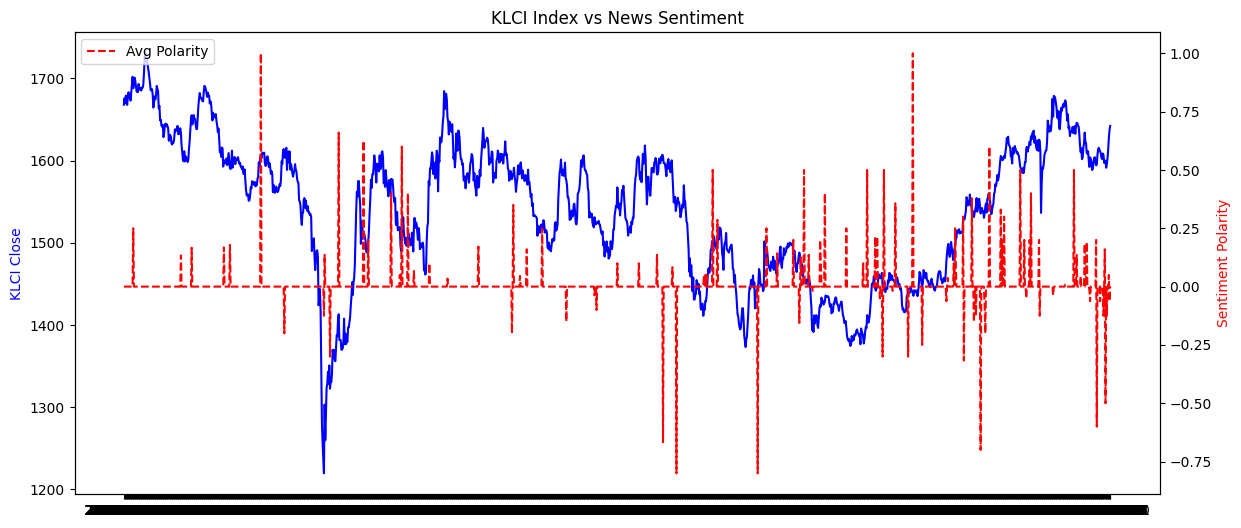

In [21]:
# Group by Date and get average polarity per day
daily_sentiment = df_merged.groupby('Date')['TextBlob_Polarity'].mean()

# Plot
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(df_merged['Date'], df_merged['Close'], color='blue', label='KLCI Close')
ax1.set_ylabel('KLCI Close', color='blue')

ax2 = ax1.twinx()
ax2.plot(df_merged['Date'], df_merged['TextBlob_Polarity'], color='red', linestyle='--', label='Avg Polarity')
ax2.set_ylabel('Sentiment Polarity', color='red')

plt.title('KLCI Index vs News Sentiment')
plt.legend(loc='upper left')
plt.show()

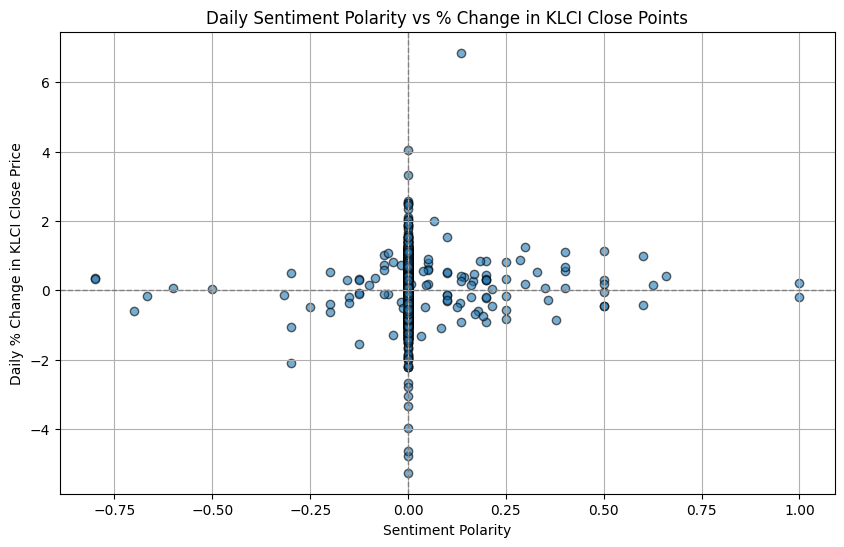

In [49]:
#Scatter Plot: Sentiment vs Index Movement - how daily sentiment scores correlate with the change in KLCI close price
# Calculate daily % change
# Calculate daily % change in Close price
df_merged['Close_Change'] = df_merged['Close'].pct_change() * 100  # in percentage

# Calculate polarity sentiment score using TextBlob
df_merged['TextBlob_Polarity'] = df_merged['headline'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Drop NaN rows resulting from pct_change at first row
df_merged.dropna(subset=['Close_Change', 'TextBlob_Polarity'], inplace=True)

# Scatter Plot: Polarity vs Close Change
plt.figure(figsize=(10, 6))
plt.scatter(df_merged['TextBlob_Polarity'], df_merged['Close_Change'], alpha=0.6, edgecolors='k')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Daily Sentiment Polarity vs % Change in KLCI Close Points')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Daily % Change in KLCI Close Price')
plt.grid(True)
plt.show()

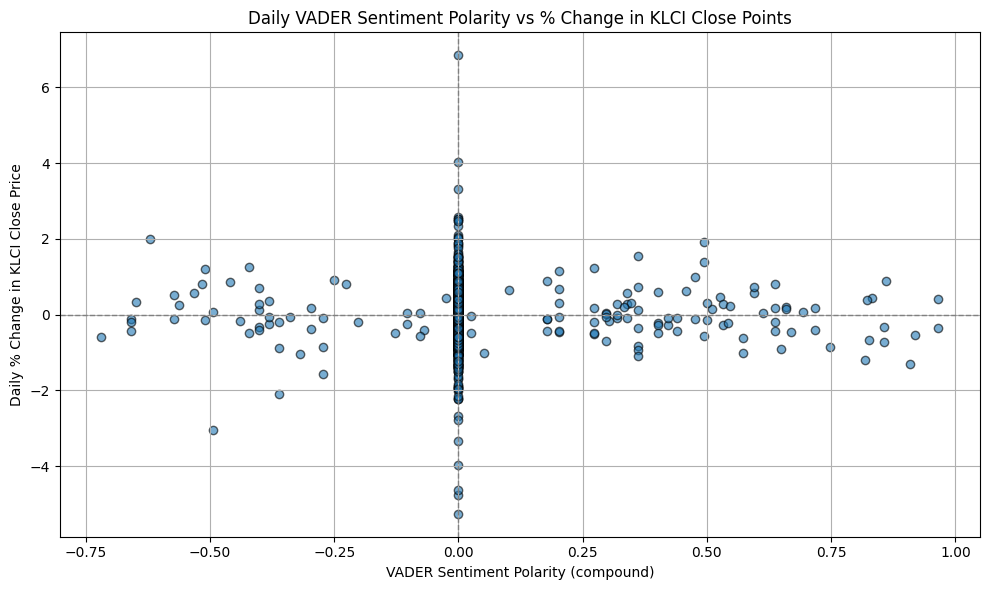

In [54]:
#Scatter Plot: Sentiment vs Index Movement - how daily sentiment scores correlate with the change in KLCI close price
# Calculate daily % change
# Calculate daily % change in Close price

# Initialize VADER sentiment analyzer
vader = SentimentIntensityAnalyzer()

# Calculate daily % change in KLCI Close price
df_merged['Close_Change'] = df_merged['Close'].pct_change() * 100  # convert to percentage

# Compute VADER compound sentiment polarity
df_merged['VADER_Sentiment'] = df_merged['headline'].astype(str).apply(lambda x: vader.polarity_scores(x)['compound'])

# Drop rows with NaNs from pct_change or missing headlines
df_merged.dropna(subset=['Close_Change', 'VADER_Sentiment'], inplace=True)

# Plot scatter of VADER polarity vs KLCI % change
plt.figure(figsize=(10, 6))
plt.scatter(df_merged['VADER_Sentiment'], df_merged['Close_Change'], alpha=0.6, edgecolors='k')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Daily VADER Sentiment Polarity vs % Change in KLCI Close Points')
plt.xlabel('VADER Sentiment Polarity (compound)')
plt.ylabel('Daily % Change in KLCI Close Price')
plt.grid(True)
plt.tight_layout()
plt.show()


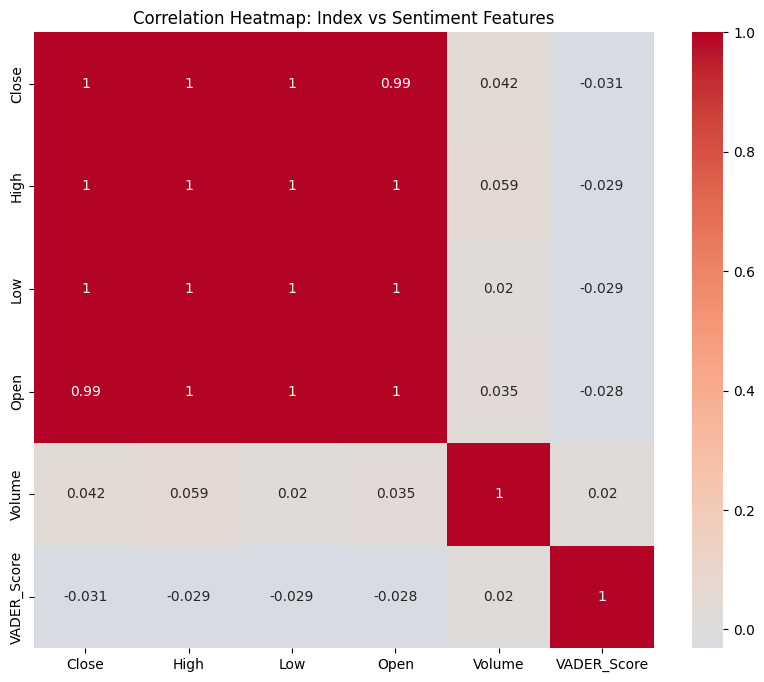

In [61]:
#Heatmap of Correlations
#Purpose: Quickly view correlations between numerical variables like Polarity, Subjectivity, VADER Score, and Index features.
import seaborn as sns

# Select relevant columns
correlation_data = df_merged[['Close', 'High', 'Low', 'Open', 'Volume', 'VADER_Score']]

# Compute correlation matrix
corr_matrix = correlation_data.corr()

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Index vs Sentiment Features')
plt.show()


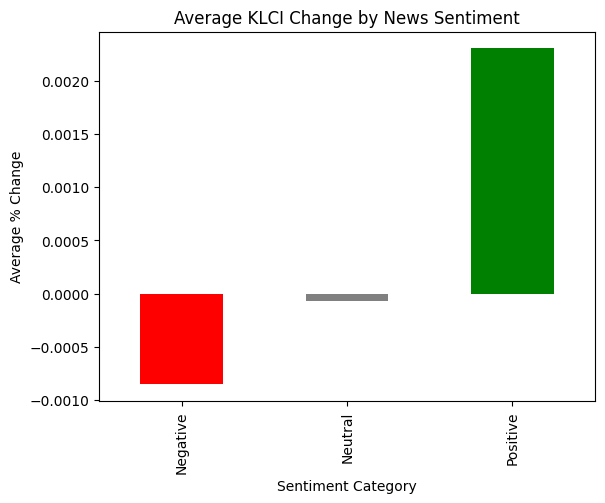

In [58]:
#Bar Plot: Average Index Change by Sentiment Category
#Purpose: See how index moves depending on headline sentiment (Positive, Neutral, Negative).
# Group by sentiment category
df_merged['Close_Change'] = df_merged['Date'].map(df_merged.set_index('Date')['Close'].pct_change())
avg_change_by_sentiment = df_merged.groupby('TextBlob_Sentiment')['Close_Change'].mean()

# Plot
avg_change_by_sentiment.plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Average KLCI Change by News Sentiment')
plt.ylabel('Average % Change')
plt.xlabel('Sentiment Category')
plt.show()


SentimentIntensityAnalyzer:

In [25]:
# Sentiment Analysis Using VADER
# Initialize VADER analyzer
sia = SentimentIntensityAnalyzer()

# Apply sentiment scoring
df_merged['VADER_Score'] = df_merged['headline'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Categorize sentiment based on VADER compound score
def categorize_vader(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_merged['VADER_Sentiment'] = df_merged['VADER_Score'].apply(categorize_vader)

# Preview
print(df_merged[['headline', 'VADER_Score', 'VADER_Sentiment']].head())

# Export to CSV
df_merged.to_csv('merged_vader_revised.csv', index=False)


  headline  VADER_Score VADER_Sentiment
1                   0.0         Neutral
2                   0.0         Neutral
3                   0.0         Neutral
4                   0.0         Neutral
5                   0.0         Neutral


LINEAR REGRESSION MODEL

In [26]:
from sklearn.metrics import mean_squared_error
import numpy as np

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [27]:
# Linear Regression for VADER-based prediction
X_vader = df_merged[['VADER_Score']]
y_vader = df_merged['Close']

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_vader, y_vader, test_size=0.2, random_state=42)
model_vader = LinearRegression()
model_vader.fit(X_train_v, y_train_v)
y_pred_vader = model_vader.predict(X_test_v)

print("VADER - RMSE:", root_mean_squared_error(y_test_v, y_pred_vader))
print("VADER - R²:", r2_score(y_test_v, y_pred_vader))


VADER - RMSE: 87.26522890271976
VADER - R²: -0.010601402016182426


In [28]:
# Linear Regression for TextBlob-based prediction
X_textblob = df_merged[['TextBlob_Polarity']]
y_textblob = df_merged['Close']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_textblob, y_textblob, test_size=0.2, random_state=42)
model_textblob = LinearRegression()
model_textblob.fit(X_train_t, y_train_t)
y_pred_textblob = model_textblob.predict(X_test_t)


print("TextBlob - RMSE:", root_mean_squared_error(y_test_t, y_pred_textblob))
print("TextBlob - R²:", r2_score(y_test_t, y_pred_textblob))

TextBlob - RMSE: 87.0188647615966
TextBlob - R²: -0.0049032677315139495


LDA Model with VADER/TextBlob Features
Prepare your features and target
Assuming your DataFrame is df_sentiment and includes:
-Polarity (from TextBlob)
-Subjectivity (from TextBlob)
-VADER_Score (from VADER)
-VADER_Sentiment (target class)

Polarity and Subjectivity: from TextBlob.
VADER_Score: from SentimentIntensityAnalyzer.

LDA works well for linearly separable data; consider comparing it with Logistic Regression or SVM later.

In [29]:
# LinearDiscriminantAnalysis Model from TextBlob
# Set Features and labels
X = df_merged[['TextBlob_Polarity', 'TextBlob_Subjectivity', 'VADER_Score']]
y = df_merged['VADER_Sentiment']

# Convert labels to numeric if needed
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

#  Train LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Make predictions
y_pred = lda.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.9897959183673469
Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      0.78      0.88         9
     Neutral       0.99      1.00      0.99       267
    Positive       1.00      0.94      0.97        18

    accuracy                           0.99       294
   macro avg       1.00      0.91      0.95       294
weighted avg       0.99      0.99      0.99       294



In [30]:
print("Label distribution:\n", pd.Series(y).value_counts())


Label distribution:
 VADER_Sentiment
Neutral     1334
Positive      89
Negative      46
Name: count, dtype: int64


In [31]:
print("Labels in test set:", np.unique(y_test))
print("All class labels:", le.classes_)


Labels in test set: [0 1 2]
All class labels: ['Negative' 'Neutral' 'Positive']


In [32]:
#Convert VADER_Sentiment to numeric
label_mapping = {
    'Down': 0,
    'Stable': 1,
    'Up': 2
}
df_merged['VADER_Sentiment_Num'] = df_merged['VADER_Sentiment'].map(label_mapping)


In [33]:
# Features and Labels
X = df_merged[['TextBlob_Polarity', 'TextBlob_Subjectivity', 'VADER_Score']]
y = df_merged['VADER_Sentiment']  # classification target 

# Encode target labels
le = LabelEncoder()
y_encoded= le.fit_transform(y)


# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y_encoded)


In [34]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

# Train the LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Predict
y_pred = lda.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n",
      classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Accuracy: 0.9488139825218477
Classification Report:
               precision    recall  f1-score   support

    Negative       1.00      0.89      0.94       267
     Neutral       0.87      1.00      0.93       267
    Positive       1.00      0.96      0.98       267

    accuracy                           0.95       801
   macro avg       0.96      0.95      0.95       801
weighted avg       0.96      0.95      0.95       801



In [35]:
df_merged[['Close', 'VADER_Score']].corr(method='spearman')


,Close,VADER_Score
Close,1.000000,-0.034509
VADER_Score,-0.034509,1.000000


In [36]:
# Select relevant features and label
features = ['VADER_Score', 'TextBlob_Polarity', 'TextBlob_Subjectivity']
target = 'Close'

In [37]:
# Normalize features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df_merged[features])
y_scaled = scaler_y.fit_transform(df_merged[[target]])

# Create sequences (LSTM expects 3D input: samples, timesteps, features)
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(time_steps, len(X)):
        Xs.append(X[i-time_steps:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

time_steps = 10
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

In [38]:
# Train-Test Split
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

BUILD LSTM MODEL

In [39]:
# Build LSTM Model
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()


c:\Users\badar\Desktop\VS Studio\Capstone 1\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Train the Model
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_data=(X_test, y_test), verbose=1)


Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1295 - val_loss: 0.0223
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0348 - val_loss: 0.0288
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0334 - val_loss: 0.0271
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0322 - val_loss: 0.0312
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0320 - val_loss: 0.0341
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0317 - val_loss: 0.0409
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0323 - val_loss: 0.0334
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0292 - val_loss: 0.0367
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0324 - val_loss: 0.0403
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0315 - val_loss: 0.0294
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0312 - val_loss: 0.0433
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.030

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step


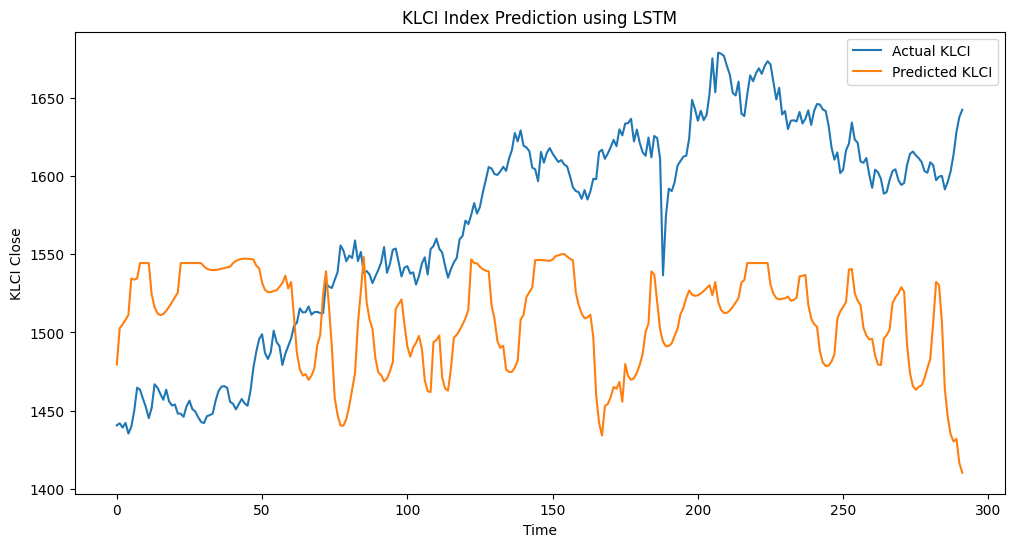

In [41]:
# Evaluate and Plot
# Predict
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

# Plot
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual KLCI')
plt.plot(y_pred, label='Predicted KLCI')
plt.title('KLCI Index Prediction using LSTM')
plt.xlabel('Time')
plt.ylabel('KLCI Close')
plt.legend()
plt.show()


Add Lagged Features (Previous Time Steps)

In [42]:
# look back for 3 days
for lag in range(1, 4):
    df_merged[f'Close_lag_{lag}'] = df_merged['Close'].shift(lag)
    df_merged[f'VADER_Score_lag_{lag}'] = df_merged['VADER_Score'].shift(lag)


In [43]:
# Add Volume
df_merged['Volume'] = df_merged['Volume'].astype(float)
df_merged['Volume'].fillna(np.nan, inplace=True)

df_model = df_merged.copy()
df_model = df_model.dropna()


C:\Users\badar\AppData\Local\Temp\ipykernel_15784\1531427658.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['Volume'].fillna(np.nan, inplace=True)


In [44]:
# KLCI Technical Analysis
df_merged['SMA_5'] = ta.SMA(df_merged['Close'], timeperiod=5)
df_merged['EMA_5'] = ta.EMA(df_merged['Close'], timeperiod=5)
df_merged['RSI_14'] = ta.RSI(df_merged['Close'], timeperiod=14)

# MACD: returns macd, signal, histogram
df_merged['MACD'], df_merged['MACD_signal'], df_merged['MACD_hist'] = ta.MACD(
    df_merged['Close'], fastperiod=12, slowperiod=26, signalperiod=9)


In [45]:
macd_line, signal_line, hist = ta.MACD(
    df_merged['Close'],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

df_merged['MACD'] = macd_line
df_merged['MACD_signal'] = signal_line
df_merged['MACD_hist'] = hist

In [46]:
df_ta = df_merged.dropna(how='all')
df_ta.head()


,Date,Close,High,Low,Open,Volume,headline,TextBlob_Polarity,TextBlob_Subjectivity,TextBlob_Sentiment,...,Close_lag_2,VADER_Score_lag_2,Close_lag_3,VADER_Score_lag_3,SMA_5,EMA_5,RSI_14,MACD,MACD_signal,MACD_hist
1,2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500.0,,0.0,0.0,Neutral,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000.0,,0.0,0.0,Neutral,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500.0,,0.0,0.0,Neutral,...,1675.829956,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900.0,,0.0,0.0,Neutral,...,1669.780029,0.0,1675.829956,0.0,NaN,NaN,NaN,NaN,NaN,NaN
5,2019-01-09,1667.829956,1684.079956,1667.829956,1679.060059,176278400.0,,0.0,0.0,Neutral,...,1679.170044,0.0,1669.780029,0.0,1673.073999,1673.073999,NaN,NaN,NaN,NaN


<BarContainer object of 1469 artists>

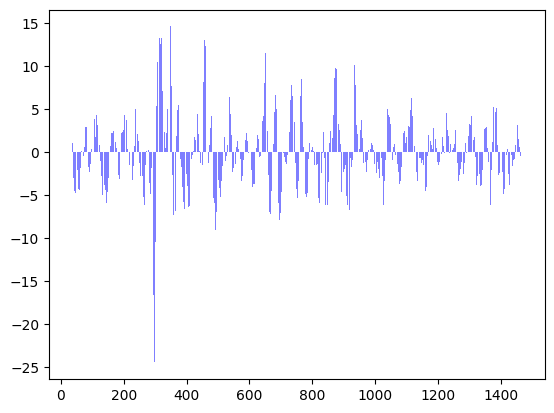

In [47]:
plt.bar(df_ta.index, df_ta['MACD_hist'], color='blue', alpha=0.5)


In [48]:
# check for headers list
print(df_ta.columns.tolist())

# save to CSV
df_ta.to_csv('compiled_datasets.csv', index=False)


['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'headline', 'TextBlob_Polarity', 'TextBlob_Subjectivity', 'TextBlob_Sentiment', 'VADER_Score', 'VADER_Sentiment', 'Close_Change', 'VADER_Sentiment_Num', 'Close_lag_1', 'VADER_Score_lag_1', 'Close_lag_2', 'VADER_Score_lag_2', 'Close_lag_3', 'VADER_Score_lag_3', 'SMA_5', 'EMA_5', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist']
